In [52]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

pd.set_option("display.max_columns", None)

In [53]:
df = pd.read_csv("AB_NYC_2019.csv")

print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

df.head()

Dataset contains 48,895 rows and 16 columns.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [54]:
df.shape

(48895, 16)

In [55]:
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [58]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [59]:
df.sample(5, random_state=42)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
879,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64354,-73.97777,Entire home/apt,89,3,62,2019-01-02,0.71,1,189
44383,34205267,"Spacious, sunny room in Queens/Brooklyn",913940,Giancarlo,Queens,Ridgewood,40.70666,-73.90779,Private room,30,21,0,NaN,NaN,1,73
15394,12342297,Private bedroom in high-ceiling 4BR apartment!,19953913,Alejandro,Manhattan,Hell's Kitchen,40.76116,-73.99016,Private room,120,2,17,2017-04-28,0.43,1,0
43230,33527778,Sonder | Stock Exchange | Stunning 3BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70763,-74.01050,Entire home/apt,470,2,5,2019-06-02,1.88,327,272
16332,13136376,Spacious 2 Bedroom with Balcony,16110448,Gingie,Manhattan,East Harlem,40.79658,-73.93287,Entire home/apt,199,2,30,2019-06-03,0.80,1,30


In [60]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


Price Distribution

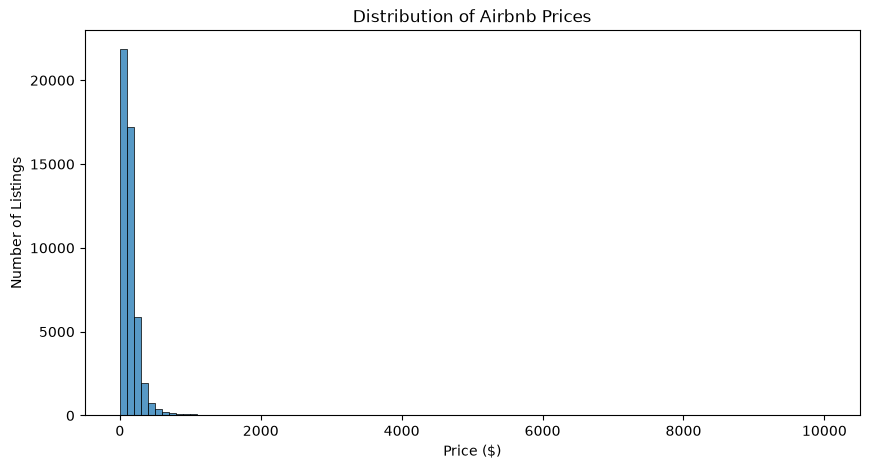

In [61]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=100)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

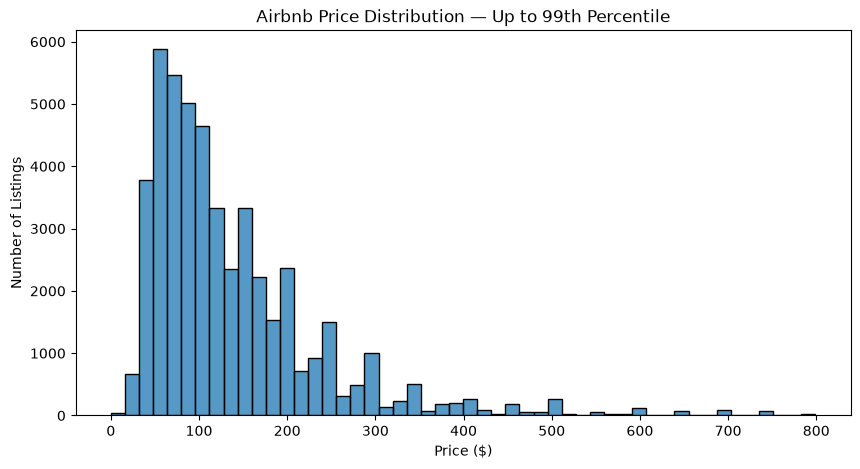

In [62]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df.loc[df["price"] <= df["price"].quantile(0.99), "price"],
    bins=50
)

plt.title("Airbnb Price Distribution — Up to 99th Percentile")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

In [63]:
print("Listings with price <= 0:", (df["price"] <= 0).sum())

Listings with price <= 0: 11


In [64]:
df = df[df["price"] > 0].copy()

print("Dataset shape:", df.shape)

Dataset shape: (48884, 16)


In [65]:
price_upper = df["price"].quantile(0.99)

print(f"99th percentile price: ${price_upper:.2f}")

99th percentile price: $799.00


In [66]:
outliers = (df["price"] > price_upper).sum()

print("Extreme price observations:", outliers)

Extreme price observations: 474


In [67]:
df = df[df["price"] <= price_upper].copy()

print("Shape after price outlier treatment:", df.shape)

Shape after price outlier treatment: (48410, 16)


Check Important Categorical Variables

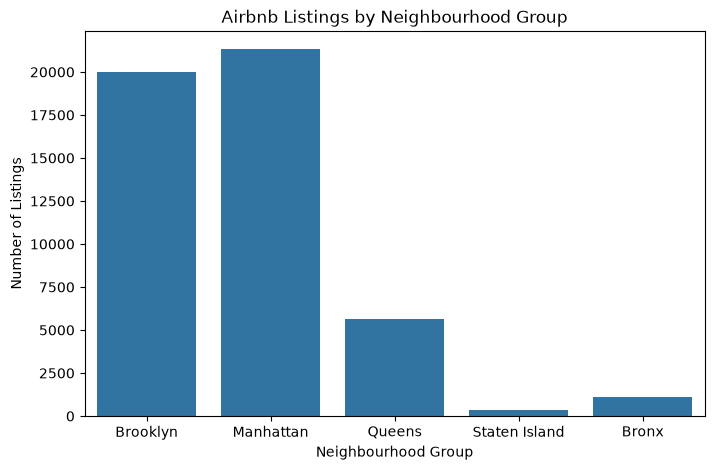

In [68]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="neighbourhood_group"
)

plt.title("Airbnb Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")

plt.show()

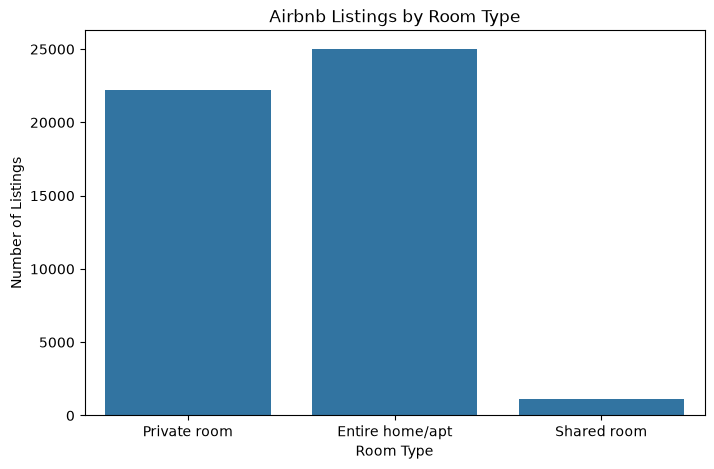

In [69]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="room_type"
)

plt.title("Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.show()

Price by Room Type

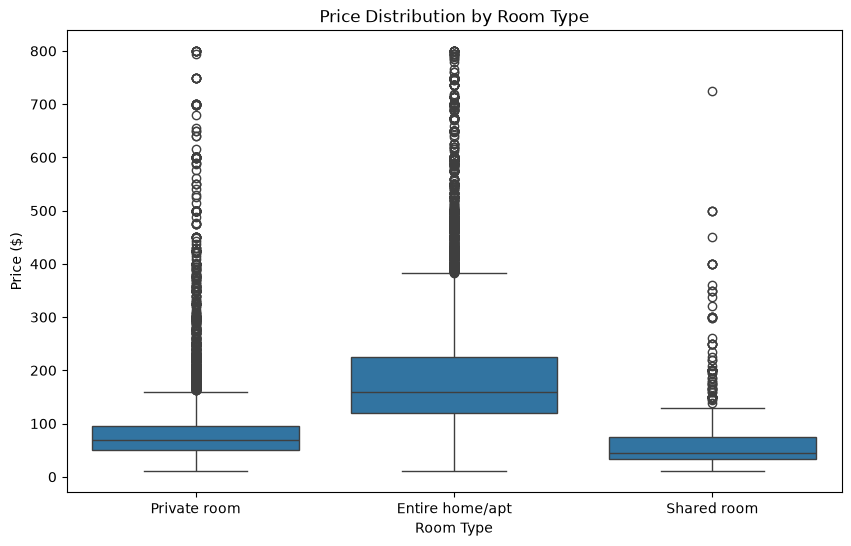

In [70]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")

plt.show()

Price by Neighbourhood Group

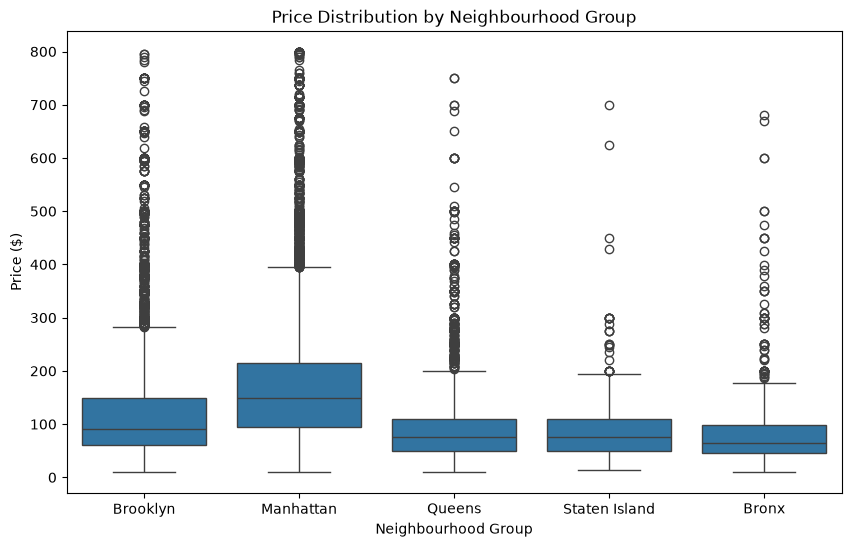

In [71]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price"
)

plt.title("Price Distribution by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")

plt.show()

Numerical Correlation

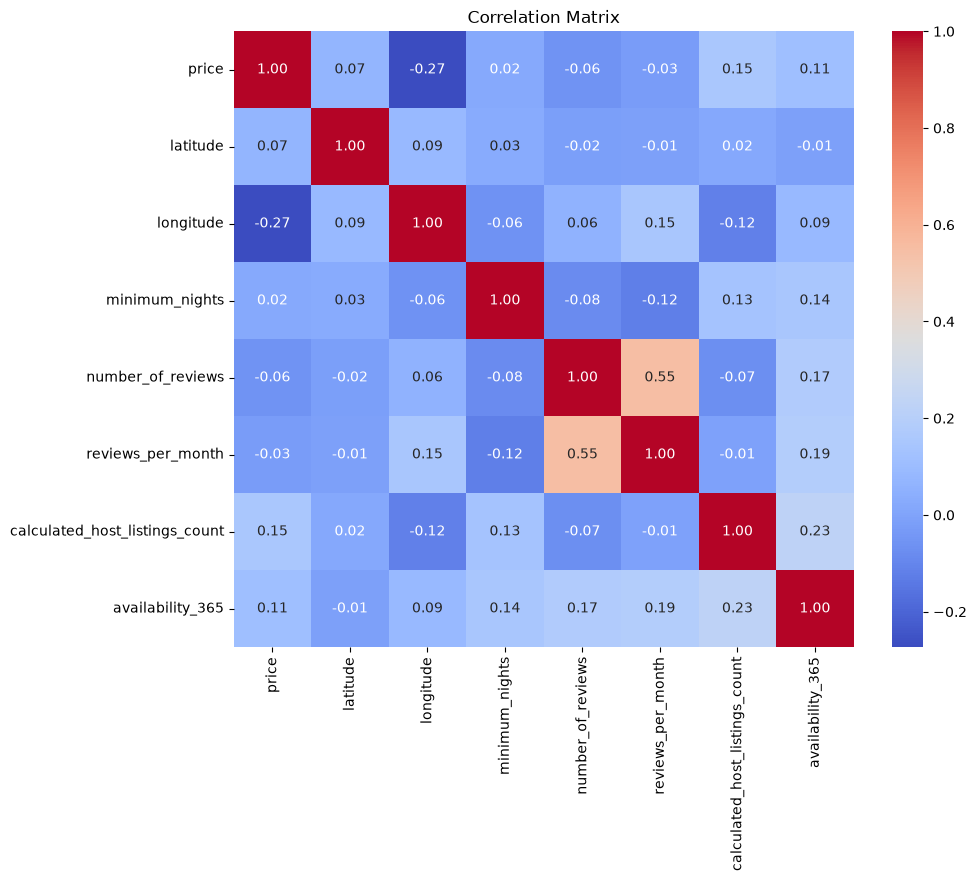

In [72]:
numeric_cols = [
    "price",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Feature Engineering

In [73]:
df["availability_ratio"] = df["availability_365"] / 365

In [74]:
df["reviews_log"] = np.log1p(df["number_of_reviews"])

In [75]:
df["minimum_nights_log"] = np.log1p(df["minimum_nights"])

In [76]:
df[
    [
        "number_of_reviews",
        "reviews_log",
        "minimum_nights",
        "minimum_nights_log",
        "availability_365",
        "availability_ratio"
    ]
].head()

,number_of_reviews,reviews_log,minimum_nights,minimum_nights_log,availability_365,availability_ratio
0,9,2.302585,1,0.693147,365,1.000000
1,45,3.828641,1,0.693147,355,0.972603
2,0,0.000000,3,1.386294,365,1.000000
3,270,5.602119,1,0.693147,194,0.531507
4,9,2.302585,10,2.397895,0,0.000000


Feature Selection

In [77]:
features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "availability_ratio",
    "reviews_log",
    "minimum_nights_log"
]

target = "price"

In [78]:
X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48410, 13)
y shape: (48410,)


Train-Test Split

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 38728
Testing samples: 9682


Define Features

In [80]:
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "availability_ratio",
    "reviews_log",
    "minimum_nights_log"
]

Preprocessing Pipeline

In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        ),

        (
            "numerical",
            SimpleImputer(strategy="median"),
            numerical_features
        )
    ]
)

Create a Model Evaluation Function

In [82]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics = {
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    }

    return metrics, test_pred

Model 1 — Ridge Regression

In [83]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=20))
])

In [84]:
ridge_metrics, ridge_pred = evaluate_model(
    ridge_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_metrics

{'Train R²': 0.4135595206361552,
 'Test R²': 0.4196723455844209,
 'MAE': 50.006036718783456,
 'RMSE': np.float64(79.46750061086772)}

Model 2 — Random Forest

In [85]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [86]:
rf_metrics, rf_pred = evaluate_model(
    rf_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_metrics

{'Train R²': 0.7095478800578434,
 'Test R²': 0.5238164075461216,
 'MAE': 44.008118590194286,
 'RMSE': np.float64(71.98468925477042)}

Model 3 — HistGradientBoosting

In [87]:
hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1
                    )
                )
            ]),
            categorical_features
        ),

        (
            "numerical",
            SimpleImputer(strategy="median"),
            numerical_features
        )
    ]
)

In [88]:
hgb_pipeline = Pipeline([
    ("preprocessor", hgb_preprocessor),
    (
        "model",
        HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        )
    )
])

In [89]:
hgb_metrics, hgb_pred = evaluate_model(
    hgb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

hgb_metrics

{'Train R²': 0.5726740872631366,
 'Test R²': 0.525412326137512,
 'MAE': 44.159518825546655,
 'RMSE': np.float64(71.86396048208829)}

Model Comparison Table

In [90]:
results = pd.DataFrame([
    {
        "Model": "Ridge Regression",
        **ridge_metrics
    },
    {
        "Model": "Random Forest",
        **rf_metrics
    },
    {
        "Model": "HistGradientBoosting",
        **hgb_metrics
    }
])

results

,Model,Train R²,Test R²,MAE,RMSE
0,Ridge Regression,0.413560,0.419672,50.006037,79.467501
1,Random Forest,0.709548,0.523816,44.008119,71.984689
2,HistGradientBoosting,0.572674,0.525412,44.159519,71.863960


In [91]:
results.sort_values("RMSE")

,Model,Train R²,Test R²,MAE,RMSE
2,HistGradientBoosting,0.572674,0.525412,44.159519,71.863960
1,Random Forest,0.709548,0.523816,44.008119,71.984689
0,Ridge Regression,0.413560,0.419672,50.006037,79.467501


In [92]:
results.sort_values("Test R²", ascending=False)

,Model,Train R²,Test R²,MAE,RMSE
2,HistGradientBoosting,0.572674,0.525412,44.159519,71.863960
1,Random Forest,0.709548,0.523816,44.008119,71.984689
0,Ridge Regression,0.413560,0.419672,50.006037,79.467501


Model Comparison Plot

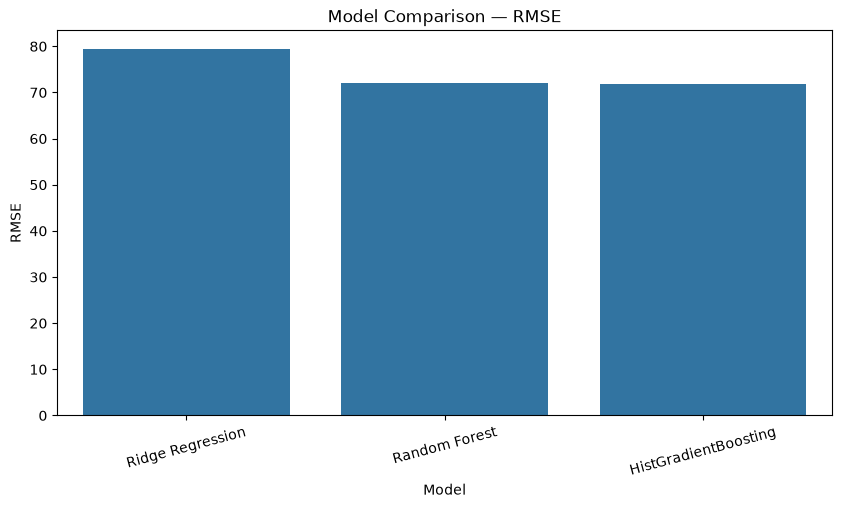

In [93]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()

Hyperparameter Tuning

In [94]:
param_distributions = {
    "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
    "model__max_iter": [150, 200, 250, 300],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0, 1, 5, 10]
}

In [95]:
random_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__l2_regularization': [0, 1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_iter': [150, 200, ...], 'model__max_leaf_nodes': [15, 31, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estim

In [96]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__max_leaf_nodes': 63, 'model__max_iter': 200, 'model__learning_rate': 0.05, 'model__l2_regularization': 5}


Final Model

In [97]:
final_model = random_search.best_estimator_

In [98]:
final_pred = final_model.predict(X_test)

In [99]:
final_mae = mean_absolute_error(y_test, final_pred)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_pred)
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print(f"MAE  : ${final_mae:.2f}")
print(f"RMSE : ${final_rmse:.2f}")
print(f"R²   : {final_r2:.4f}")

MAE  : $44.18
RMSE : $71.93
R²   : 0.5246


Overfitting / Underfitting Check

In [100]:
train_pred = final_model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, final_pred)

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R² : {test_r2:.4f}")
print(f"R² gap     : {train_r2 - test_r2:.4f}")

Training R²: 0.5746
Testing R² : 0.5246
R² gap     : 0.0500


In [101]:
train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, final_pred)
)

print(f"Training RMSE: ${train_rmse:.2f}")
print(f"Testing RMSE : ${test_rmse:.2f}")   

Training RMSE: $67.60
Testing RMSE : $71.93


Actual vs Predicted Plot

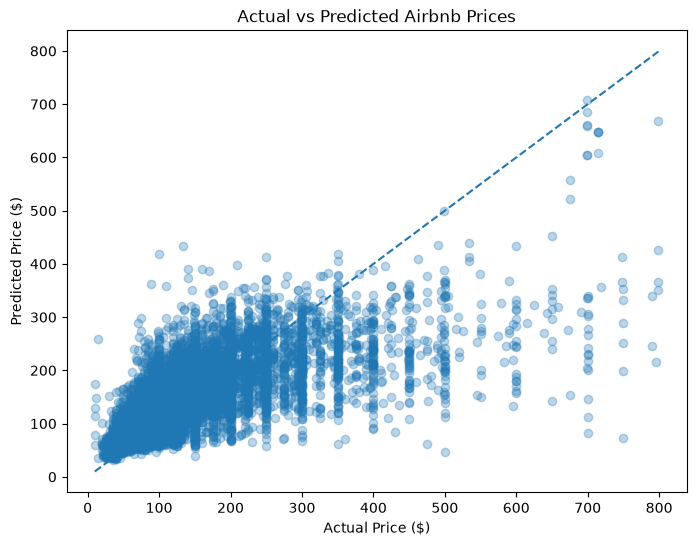

In [102]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_pred,
    alpha=0.3
)

min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

Residual Analysis

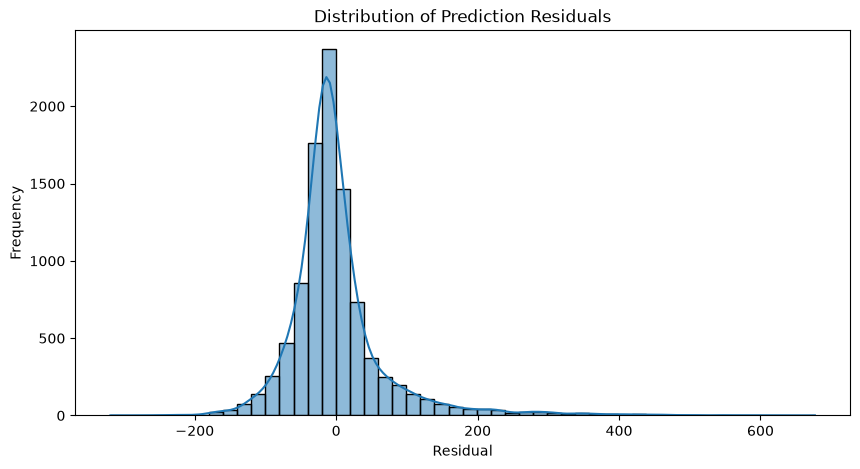

In [103]:
residuals = y_test - final_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

Save the Final Pipeline

In [104]:
joblib.dump(
    final_model,
    "airbnb_price_model.pkl"
)

print("Final model pipeline saved successfully.")

Final model pipeline saved successfully.


In [105]:
import os

print(
    "File exists:",
    os.path.exists("airbnb_price_model.pkl")
)

File exists: True


In [106]:
final_model = random_search.best_estimator_

In [107]:
joblib.dump(
    final_model,
    "airbnb_price_model.pkl"
)

['airbnb_price_model.pkl']

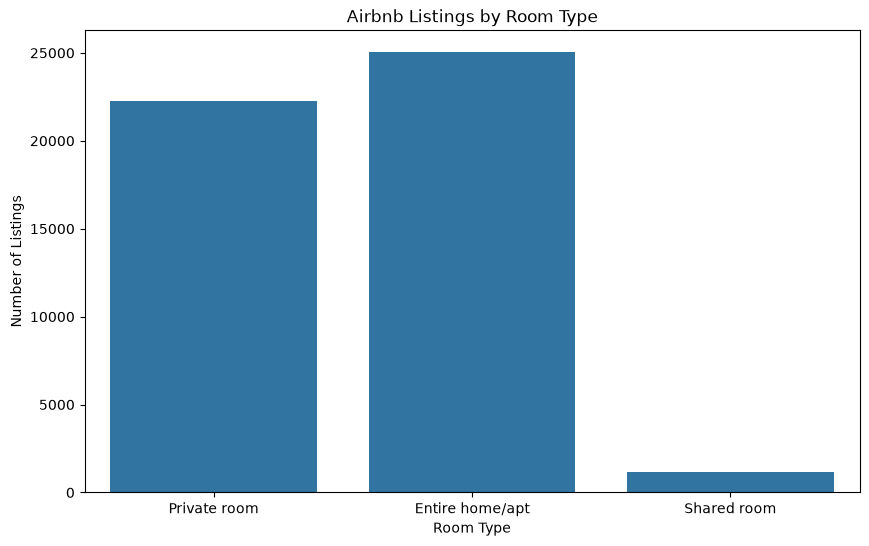

In [108]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="room_type"
)

plt.title("Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.savefig(
    "screenshots/01_eda.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

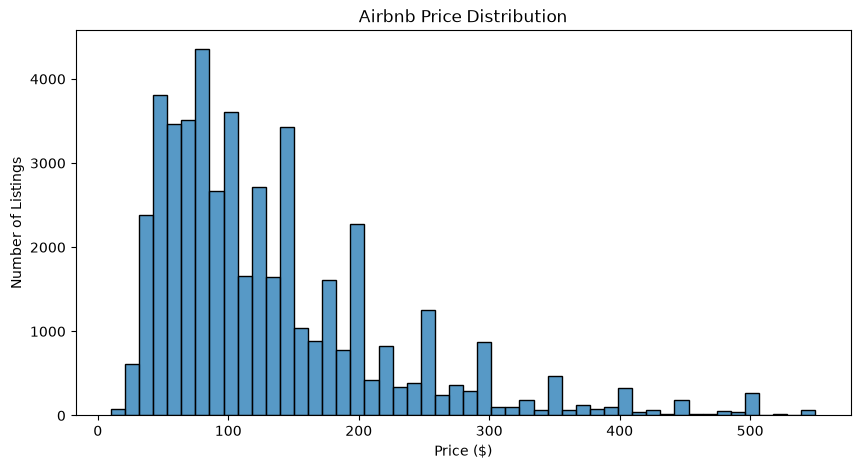

In [109]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df.loc[
        df["price"] <= df["price"].quantile(0.99),
        "price"
    ],
    bins=50
)

plt.title("Airbnb Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.savefig(
    "screenshots/02_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

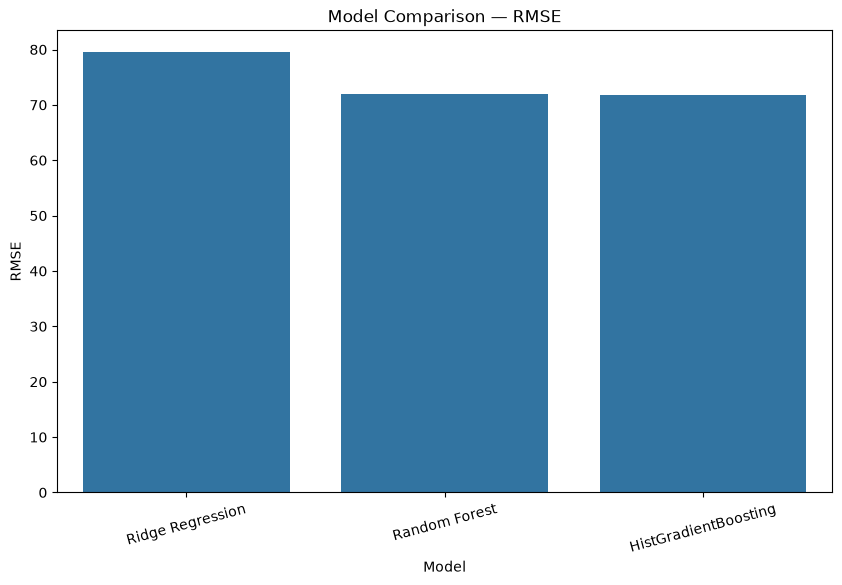

In [110]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.savefig(
    "screenshots/03_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

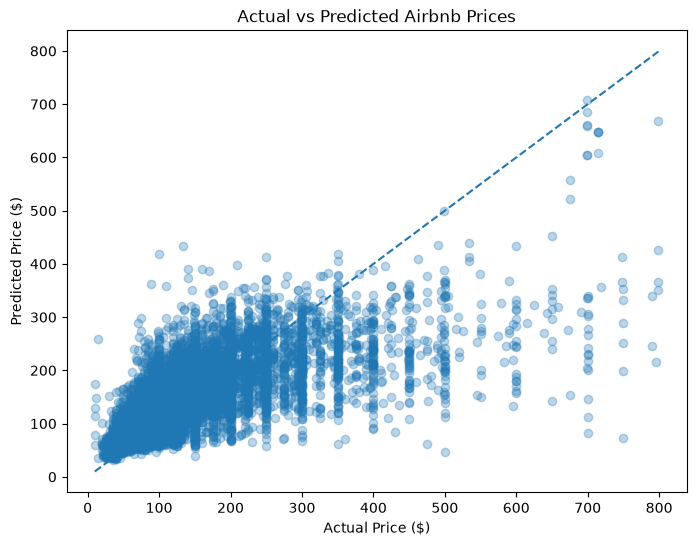

In [111]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_pred,
    alpha=0.3
)

min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")

plt.savefig(
    "screenshots/04_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()